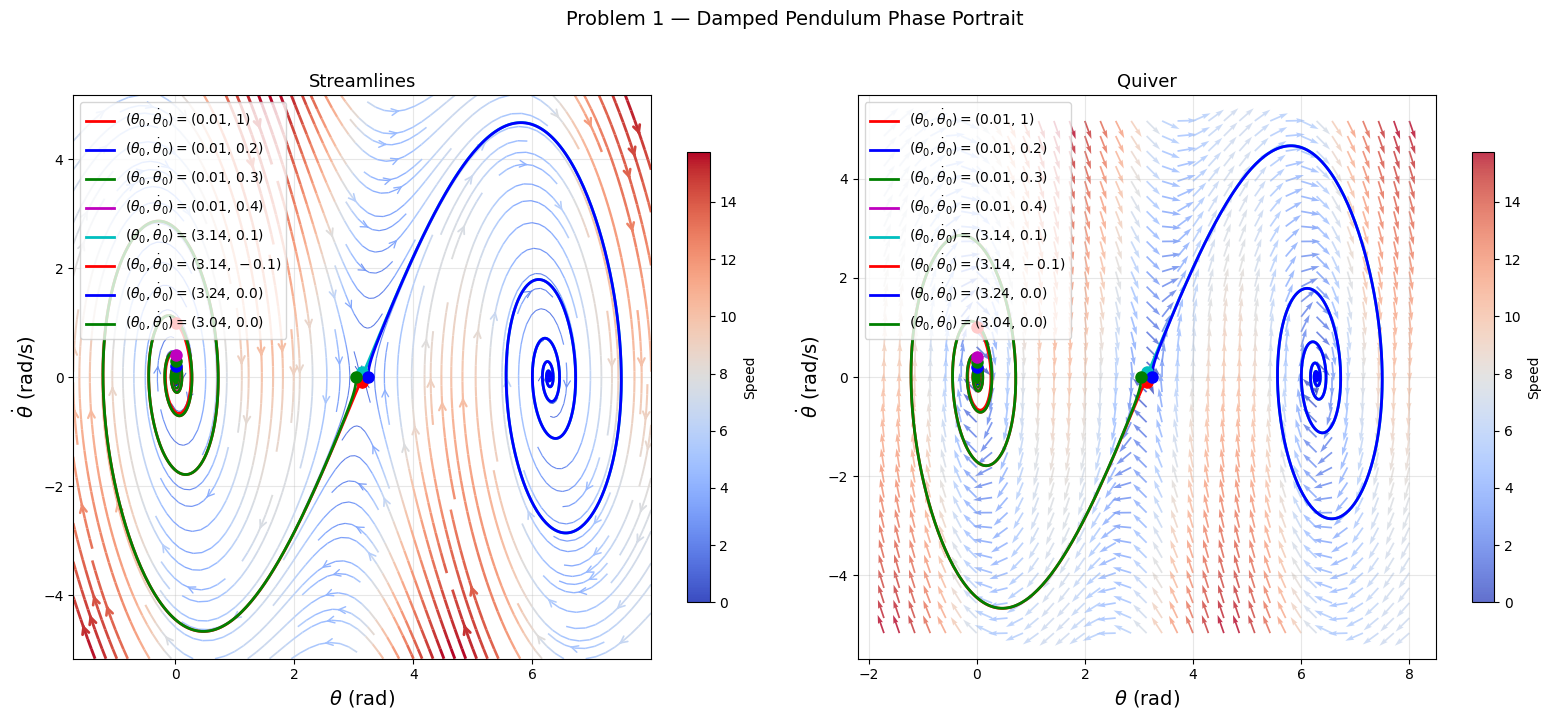

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# ── Reusable phase-portrait plotters ──

def plot_phase_quiver(X1, X2, U, V, ax=None, title='Quiver', trajectories=None,
                      xlabel=r'$x_1$', ylabel=r'$x_2$', extra_artists=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
    else:
        fig = ax.get_figure()

    speed = np.sqrt(U**2 + V**2)
    speed_safe = speed.copy()
    speed_safe[speed_safe == 0] = 1
    U_norm = U / speed_safe
    V_norm = V / speed_safe

    q = ax.quiver(X1, X2, U_norm, V_norm, speed, cmap='coolwarm',
                  scale=30, width=0.003, alpha=0.8)
    fig.colorbar(q, ax=ax, label='Speed', shrink=0.8)

    if trajectories:
        colors = ['r', 'b', 'g', 'm', 'c']
        for i, traj in enumerate(trajectories):
            if len(traj) == 3:
                x, y, label = traj
            else:
                x, y = traj
                label = f'IC {i+1}'
            ax.plot(x, y, f'{colors[i % len(colors)]}-', linewidth=2, label=label)
            ax.plot(x[0], y[0], f'{colors[i % len(colors)]}o', markersize=8, zorder=5)

    if extra_artists:
        extra_artists(ax)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    return ax


def plot_phase_streamlines(X1, X2, U, V, ax=None, title='Streamlines', trajectories=None,
                           xlabel=r'$x_1$', ylabel=r'$x_2$', extra_artists=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
    else:
        fig = ax.get_figure()

    speed = np.sqrt(U**2 + V**2)
    speed_safe = speed.copy()
    speed_safe[speed_safe == 0] = 1
    lw = 0.6 + 1.5 * speed / speed_safe.max()

    strm = ax.streamplot(X1, X2, U, V, color=speed, cmap='coolwarm',
                         linewidth=lw, density=1.8, arrowsize=1.2, arrowstyle='->')
    fig.colorbar(strm.lines, ax=ax, label='Speed', shrink=0.8)

    if trajectories:
        colors = ['r', 'b', 'g', 'm', 'c']
        for i, traj in enumerate(trajectories):
            if len(traj) == 3:
                x, y, label = traj
            else:
                x, y = traj
                label = f'IC {i+1}'
            ax.plot(x, y, f'{colors[i % len(colors)]}-', linewidth=2, label=label)
            ax.plot(x[0], y[0], f'{colors[i % len(colors)]}o', markersize=8, zorder=5)

    if extra_artists:
        extra_artists(ax)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    return ax


# ── Problem 1: damped pendulum ──

def integrate_euler(state, state_dot, dt):
    return state + state_dot * dt


def simulate_pendulum(m=1.0, l=1.0, k=1.0, g=9.81, N=10000, z0=[4.0, 1.0]):
    z = np.zeros((4, N))
    dt = 0.01
    z[0, 0] = z0[0]
    z[1, 0] = z0[1]
    for i in range(N - 1):
        theta = z[0, i]
        theta_dot = z[1, i]
        theta_dot_dot = -(g / l) * np.sin(theta) - (k / m) * theta_dot
        z[0, i + 1] = integrate_euler(theta, theta_dot, dt)
        z[1, i + 1] = integrate_euler(theta_dot, theta_dot_dot, dt)
        z[2, i + 1] = theta_dot_dot
    return z[0], z[1]


def problem_1():
    initial_conditions = [
        [0.01, 1], [0.01, 0.2], [0.01, 0.3], [0.01, 0.4],
        [np.pi, 0.1], [np.pi, -0.1], [np.pi + 0.1, 0.0], [np.pi - 0.1, 0.0],
    ]
    m, l, k, g = 1.0, 1.0, 1.0, 9.81

    results = []
    for z0 in initial_conditions:
        theta, theta_dot = simulate_pendulum(z0=z0)
        label = rf'$(\theta_0, \dot{{\theta}}_0) = ({z0[0]:.2f},\, {z0[1]})$'
        results.append((theta, theta_dot, label))

    # Build grid from trajectory extents
    all_theta = np.concatenate([r[0] for r in results])
    all_theta_dot = np.concatenate([r[1] for r in results])
    th = np.linspace(min(all_theta) - 0.5, max(all_theta) + 0.5, 35)
    th_d = np.linspace(min(all_theta_dot) - 0.5, max(all_theta_dot) + 0.5, 35)
    TH, TH_D = np.meshgrid(th, th_d)
    dTH = TH_D
    dTH_D = -(g / l) * np.sin(TH) - (k / m) * TH_D

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    plot_phase_streamlines(TH, TH_D, dTH, dTH_D, ax=ax1, title='Streamlines',
                           trajectories=results,
                           xlabel=r'$\theta$ (rad)', ylabel=r'$\dot{\theta}$ (rad/s)')
    plot_phase_quiver(TH, TH_D, dTH, dTH_D, ax=ax2, title='Quiver',
                      trajectories=results,
                      xlabel=r'$\theta$ (rad)', ylabel=r'$\dot{\theta}$ (rad/s)')
    fig.suptitle('Problem 1 — Damped Pendulum Phase Portrait', fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig('images/problem1_damped_pendulum.png', dpi=150, bbox_inches='tight')
    plt.show()

problem_1()

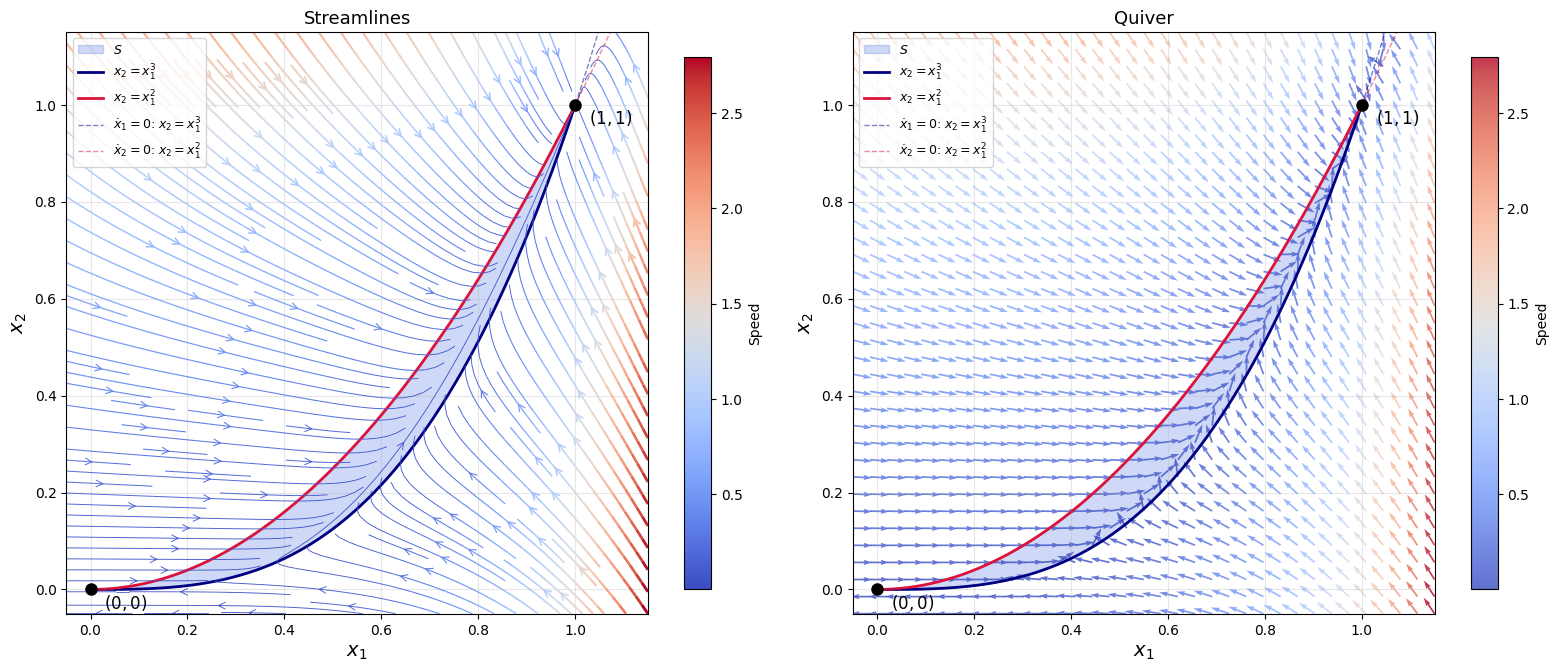

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0, 1, 500)

# Boundaries of S
lower = x1**3
upper = x1**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax in (ax1, ax2):
    ax.fill_between(x1, lower, upper, alpha=0.25, color='royalblue', label=r'$S$')
    ax.plot(x1, lower, color='navy', linewidth=2, label=r'$x_2 = x_1^3$')
    ax.plot(x1, upper, color='crimson', linewidth=2, label=r'$x_2 = x_1^2$')

# Shared grid
X1, X2 = np.meshgrid(np.linspace(-0.05, 1.15, 35), np.linspace(-0.05, 1.15, 35))
U = -X1**3 + X2
V = X1**6 - X2**3
speed = np.sqrt(U**2 + V**2)
speed_safe = speed.copy()
speed_safe[speed_safe == 0] = 1

# --- Left: Streamplot ---
lw = 0.6 + 1.5 * speed / speed_safe.max()
strm = ax1.streamplot(X1, X2, U, V, color=speed, cmap='coolwarm', linewidth=lw,
                       density=1.8, arrowsize=1.2, arrowstyle='->')
fig.colorbar(strm.lines, ax=ax1, label='Speed', shrink=0.8)
ax1.set_title('Streamlines', fontsize=13)

# --- Right: Quiver ---
U_norm = U / speed_safe
V_norm = V / speed_safe
q = ax2.quiver(X1, X2, U_norm, V_norm, speed, cmap='coolwarm', scale=30, width=0.003, alpha=0.8)
fig.colorbar(q, ax=ax2, label='Speed', shrink=0.8)
ax2.set_title('Quiver', fontsize=13)

# Nullclines, equilibria, labels for both
x1_fine = np.linspace(0.001, 1.15, 500)
nc1 = x1_fine**3
nc2 = x1_fine**2

for ax in (ax1, ax2):
    ax.plot(x1_fine, nc1, '--', color='navy', linewidth=1, alpha=0.5, label=r'$\dot{x}_1=0$: $x_2=x_1^3$')
    ax.plot(x1_fine, nc2, '--', color='crimson', linewidth=1, alpha=0.5, label=r'$\dot{x}_2=0$: $x_2=x_1^2$')
    ax.plot(0, 0, 'ko', markersize=8, zorder=5)
    ax.plot(1, 1, 'ko', markersize=8, zorder=5)
    ax.annotate('$(0,0)$', (0, 0), textcoords='offset points', xytext=(10, -14), fontsize=12)
    ax.annotate('$(1,1)$', (1, 1), textcoords='offset points', xytext=(10, -14), fontsize=12)
    ax.set_xlabel(r'$x_1$', fontsize=14)
    ax.set_ylabel(r'$x_2$', fontsize=14)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(-0.05, 1.15)
    ax.set_ylim(-0.05, 1.15)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('images/problem2_invariant_set.png', dpi=150, bbox_inches='tight')


### Ex5. SoS

In [11]:
from pydrake.all import (
    MathematicalProgram, Solve, Variables,
    MonomialBasis, Polynomial
)
import numpy as np

prog = MathematicalProgram()

# State variables
x = prog.NewIndeterminates(2, "x")

# Define dynamics
#   x1_dot = x2
#   x2_dot = -x1 - x2 - x1^3
f = [x[1],
     -x[0] - x[1] - x[0]**3]

# Lyapunov candidate V(x) as free polynomial of degree 4
V_poly = prog.NewFreePolynomial(Variables(x), 4)
V = V_poly.ToExpression()

# Compute Vdot = dV/dx1 * f1 + dV/dx2 * f2
Vdot = sum(V.Differentiate(x[i]) * f[i] for i in range(2))

# Constraint 1: V(x) - epsilon * ||x||^2 is SOS  (positive definiteness)
prog.AddSosConstraint(V - 1e-4 * (x[0]**2 + x[1]**2))

# Constraint 2: -Vdot(x) - epsilon * ||x||^2 is SOS  (negative definiteness of Vdot)
prog.AddSosConstraint(-Vdot - 1e-4 * (x[0]**2 + x[1]**2))

# Constraint 3: V(0) = 0
prog.AddLinearConstraint(V.EvaluatePartial({x[0]: 0, x[1]: 0}) == 0)

result = Solve(prog)
print(f"Success: {result.is_success()}")

# Extract the Lyapunov function
V_solution = result.GetSolution(V_poly).ToExpression()
print(f"V(x) = {V_solution}")

Success: True
V(x) = (2.0415109335964733e-12 + 3.6029404187065405e-31 * x(0) + 5.8431719851501214e-30 * x(1) + 0.83221788451330037 * (x(0) * x(1)) + 5.5873429812920906e-19 * (x(0) * pow(x(1), 2)) + 9.4016382354080692e-09 * (x(0) * pow(x(1), 3)) + 1.1326467362438939e-16 * (pow(x(0), 2) * x(1)) + 3.2157852613997231e-08 * (pow(x(0), 2) * pow(x(1), 2)) + 9.1936150693872361e-05 * (pow(x(0), 3) * x(1)) + 1.5843482992862929 * pow(x(0), 2) - 6.8335114650141125e-15 * pow(x(0), 3) + 0.80419568077788739 * pow(x(0), 4) + 1.6077011740629628 * pow(x(1), 2) - 3.0091073282460801e-21 * pow(x(1), 3) + 6.2479942458522225e-10 * pow(x(1), 4))


In [12]:
from pydrake.all import Evaluate

# Extract and clean up
V_solution = result.GetSolution(V_poly)
coeff_map = V_solution.monomial_to_coefficient_map()

tol = 1e-3
V_clean = 0
for monomial, coeff in coeff_map.items():
    # Evaluate the coefficient to a plain float
    coeff_val = coeff.Evaluate()
    if abs(coeff_val) > tol:
        V_clean += round(coeff_val, 4) * monomial.ToExpression()

print(f"V_clean(x) = {V_clean}")

V_clean(x) = (0.83220000000000005 * (x(0) * x(1)) + 1.5843 * pow(x(0), 2) + 0.80420000000000003 * pow(x(0), 4) + 1.6076999999999999 * pow(x(1), 2))


In [ ]:
# Use the known Lyapunov function directly
V_clean = 1.584*x[0]**2 + 0.832*x[0]*x[1] + 1.608*x[1]**2 + 0.804*x[0]**4
c = 1.0
B = V_clean - c
Bdot = sum(B.Differentiate(x[i]) * f[i] for i in range(2))

# Only need to find lambda
lam_poly = prog.NewSosPolynomial(Variables(x), 2)[0]
lam = lam_poly.ToExpression()
prog.AddSosConstraint(-Bdot - lam * B)
result = Solve(prog)
print(f"Success: {result.is_success()}")

Success: True
